# Predicting Bi-Hourly Station-Level Bike Demand + Interactive Map

For each of the 60 active POGOH stations, predict how many bikes will
**arrive** and **depart** in each 2-hour window of the day, then visualize on
an interactive map with:

- A **time slider** to scrub through predicted demand bi-hourly across the 7
  days after our trip data ends.
- A **live** view of actual current bike/dock availability from POGOH's
  real-time feed - including the **e-bike vs. classic bike split**, which is
  only available live (see note in section 5 - the historical trip export
  has no vehicle-type column).
- Toggleable **bike infrastructure overlays**: bike lanes, protected lanes,
  trails, sharrows, on-street routes, cautionary routes, and bikeable
  sidewalks.


In [1]:
import sys
sys.path.insert(0, '../src')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

from load_data import (load_trips, load_stations, load_weather, load_weather_with_forecast,
                        fetch_live_station_status, load_bike_infrastructure)
from build_map import build_demand_map
from predict import FEATURES, add_calendar_features, build_future_frame, simulate_bike_stock, save_models

trips = load_trips()
stations = load_stations()
weather = load_weather()
infra = load_bike_infrastructure()
print(f"{len(trips):,} raw trips | {len(weather)} days of weather | {len(infra)} infrastructure layers")

1,703,174 raw trips | 1598 days of weather | 7 infrastructure layers


## 1. Build the bi-hourly station panel

Same stable-network window as before (2023-07 onward, 60 stations). Arrivals
are binned by each trip's actual *end* timestamp; departures by *start*
timestamp - each rounded down to its 2-hour window (00:00, 02:00, ...,
22:00).

In [2]:
STABLE_START = pd.Timestamp('2023-07-01')
active_ids = set(stations['id'])
trips_stable = trips[
    (trips['start_date'] >= STABLE_START) &
    (trips['start_station_id'].isin(active_ids)) &
    (trips['end_station_id'].isin(active_ids))
].copy()
trips_stable['dep_bin'] = trips_stable['start_date'].dt.floor('2h')
trips_stable['arr_bin'] = trips_stable['end_date'].dt.floor('2h')

bin_range = pd.date_range(trips_stable['dep_bin'].min(), trips_stable['dep_bin'].max(), freq='2h')
station_ids = sorted(active_ids)

arrivals = trips_stable.groupby(['arr_bin', 'end_station_id']).size().rename('arrivals')
departures = trips_stable.groupby(['dep_bin', 'start_station_id']).size().rename('departures')

panel_index = pd.MultiIndex.from_product([bin_range, station_ids], names=['bin', 'station_id'])
panel = pd.DataFrame(index=panel_index).reset_index()
panel = panel.merge(arrivals.rename_axis(['bin', 'station_id']).reset_index(), on=['bin', 'station_id'], how='left')
panel = panel.merge(departures.rename_axis(['bin', 'station_id']).reset_index(), on=['bin', 'station_id'], how='left')
panel[['arrivals', 'departures']] = panel[['arrivals', 'departures']].fillna(0)
panel['net_flow'] = panel['arrivals'] - panel['departures']
panel['date'] = panel['bin'].dt.normalize()
panel = panel.merge(weather, on='date', how='left')

print(f"panel: {len(panel):,} station-bins ({len(bin_range):,} bi-hourly bins x {len(station_ids)} stations)")
panel.head()

panel: 833,760 station-bins (13,896 bi-hourly bins x 60 stations)


,bin,station_id,arrivals,departures,net_flow,date,temp_max_c,temp_min_c,precip_mm,snow_cm,temp_avg_c
0,2023-07-01,1,0.0,0.0,0.0,2023-07-01,27.8,19.1,11.7,0.0,23.45
1,2023-07-01,2,0.0,0.0,0.0,2023-07-01,27.8,19.1,11.7,0.0,23.45
2,2023-07-01,3,0.0,0.0,0.0,2023-07-01,27.8,19.1,11.7,0.0,23.45
3,2023-07-01,4,0.0,0.0,0.0,2023-07-01,27.8,19.1,11.7,0.0,23.45
4,2023-07-01,5,0.0,1.0,-1.0,2023-07-01,27.8,19.1,11.7,0.0,23.45


## 2. Feature engineering

In [3]:
# add_calendar_features / FEATURES come from src/predict.py - the SAME module
# src/daily_refresh.py uses, so training and the fast daily re-prediction can never drift apart.
panel = add_calendar_features(panel)
panel['is_freezing'] = (panel['temp_min_c'] <= 0).astype(int)
panel['is_rainy'] = (panel['precip_mm'] > 2).astype(int)

TRAIN_CUTOFF = panel['bin'].max() - pd.Timedelta(days=60)
train = panel[panel['bin'] <= TRAIN_CUTOFF].copy()
test = panel[panel['bin'] > TRAIN_CUTOFF].copy()
print(f"train: {len(train):,} rows   test: {len(test):,} rows")

# Per-station, per-hour-of-day baseline (train only) - both a feature and our naive baseline
station_hour_avg = train.groupby(['station_id', 'hour'])[['arrivals', 'departures']].mean()
station_hour_avg.columns = ['station_hour_avg_arrivals', 'station_hour_avg_departures']
train = train.merge(station_hour_avg, on=['station_id', 'hour'], how='left')
test = test.merge(station_hour_avg, on=['station_id', 'hour'], how='left')
train.head()

train: 790,560 rows   test: 43,200 rows


,bin,station_id,arrivals,departures,net_flow,date,temp_max_c,temp_min_c,precip_mm,snow_cm,...,hour_cos,day_of_week,is_weekend,month,doy_sin,doy_cos,is_freezing,is_rainy,station_hour_avg_arrivals,station_hour_avg_departures
0,2023-07-01,1,0.0,0.0,0.0,2023-07-01,27.8,19.1,11.7,0.0,...,1.0,5,1,7,0.010751,-0.999942,0,1,0.361566,0.577413
1,2023-07-01,2,0.0,0.0,0.0,2023-07-01,27.8,19.1,11.7,0.0,...,1.0,5,1,7,0.010751,-0.999942,0,1,0.223133,0.163934
2,2023-07-01,3,0.0,0.0,0.0,2023-07-01,27.8,19.1,11.7,0.0,...,1.0,5,1,7,0.010751,-0.999942,0,1,0.033698,0.028233
3,2023-07-01,4,0.0,0.0,0.0,2023-07-01,27.8,19.1,11.7,0.0,...,1.0,5,1,7,0.010751,-0.999942,0,1,0.230419,0.105647
4,2023-07-01,5,0.0,1.0,-1.0,2023-07-01,27.8,19.1,11.7,0.0,...,1.0,5,1,7,0.010751,-0.999942,0,1,0.278689,0.377049


## 3. Train Random Forest models (arrivals + departures)

Arrivals     | RF: MAE=1.621 R2=0.551  |  naive station-hour-avg baseline MAE=1.821  (+11.0%)
Departures   | RF: MAE=1.656 R2=0.531  |  naive station-hour-avg baseline MAE=1.839  (+10.0%)


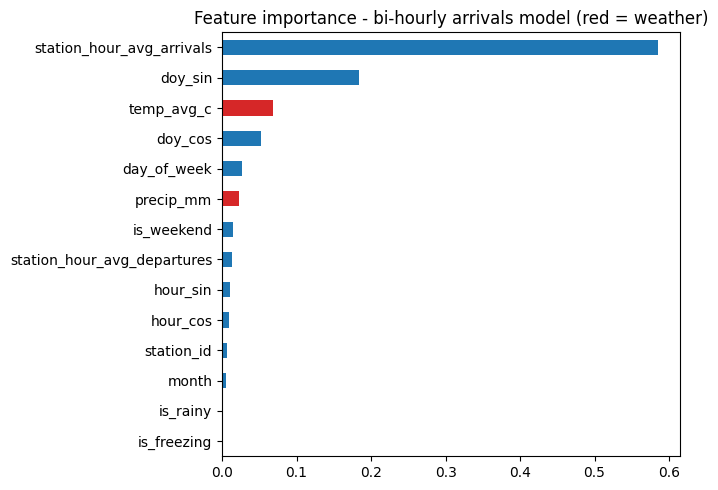

In [4]:
rf_arrivals = RandomForestRegressor(n_estimators=200, max_depth=14, min_samples_leaf=3, random_state=42, n_jobs=-1)
rf_departures = RandomForestRegressor(n_estimators=200, max_depth=14, min_samples_leaf=3, random_state=42, n_jobs=-1)
rf_arrivals.fit(train[FEATURES], train['arrivals'])
rf_departures.fit(train[FEATURES], train['departures'])

test['pred_arrivals'] = rf_arrivals.predict(test[FEATURES])
test['pred_departures'] = rf_departures.predict(test[FEATURES])

def report(y_true, y_pred, baseline_pred, label):
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    base_mae = mean_absolute_error(y_true, baseline_pred)
    print(f"{label:12s} | RF: MAE={mae:.3f} R2={r2:.3f}  |  naive station-hour-avg baseline MAE={base_mae:.3f}  ({(1-mae/base_mae)*100:+.1f}%)")

report(test['arrivals'], test['pred_arrivals'], test['station_hour_avg_arrivals'], 'Arrivals')
report(test['departures'], test['pred_departures'], test['station_hour_avg_departures'], 'Departures')

importances = pd.Series(rf_arrivals.feature_importances_, index=FEATURES).sort_values()
fig, ax = plt.subplots(figsize=(7, 5))
colors = ['#d62728' if f in ('temp_avg_c','precip_mm','is_freezing','is_rainy') else '#1f77b4' for f in importances.index]
importances.plot(kind='barh', ax=ax, color=colors)
ax.set_title('Feature importance - bi-hourly arrivals model (red = weather)')
plt.tight_layout()
plt.savefig('../docs/demand_model_feature_importance.png', dpi=150)
plt.show()

## 4. Predict bi-hourly demand for the next ~7 days (from today)

Anchored to whenever this notebook runs, not a fixed date - re-execute it
later and the prediction window rolls forward automatically. Dates from
today onward use Open-Meteo's real weather **forecast** (refreshed by
`fetch_data.py`, up to 16 days out); there's a real gap between the latest
available trip data (WPRDC publishes monthly, with lag) and today, but since
the model predicts from station identity + calendar/weather features rather
than a running time series, that gap doesn't affect prediction quality.

In addition to arrivals/departures/net-flow (a rate), this section also
simulates a predicted **bike count** (a stock) per station per bin: starting
from each station's live bike count right now, walk forward bin by bin
adding the predicted net flow, clipped to [0, capacity]. This is a simple
cumulative simulation on top of the per-bin model, not a separate model - so
its errors compound the further out you look, unlike net-flow which is a
fresh prediction each bin. Treat later-in-the-week bike-count estimates as
rougher than net-flow at the same horizon.

That predicted stock is further split into **classic vs. e-bike** using
each station's *current live* e-bike fraction, held constant going forward
- this is an approximation on top of an approximation, not a trained model:
there's no historical vehicle-type data to learn how e-bike vs. classic
demand actually differs, so "today's on-the-ground mix, projected forward"
is the best available proxy. Don't read too much into small classic/e-bike
differences late in the week.

In [5]:
station_hour_avg_full = panel.groupby(['station_id', 'hour'])[['arrivals', 'departures']].mean()
station_hour_avg_full.columns = ['station_hour_avg_arrivals', 'station_hour_avg_departures']
panel_full = panel.merge(station_hour_avg_full, on=['station_id', 'hour'], how='left')

rf_arrivals_full = RandomForestRegressor(n_estimators=200, max_depth=14, min_samples_leaf=3, random_state=42, n_jobs=-1)
rf_departures_full = RandomForestRegressor(n_estimators=200, max_depth=14, min_samples_leaf=3, random_state=42, n_jobs=-1)
rf_arrivals_full.fit(panel_full[FEATURES], panel_full['arrivals'])
rf_departures_full.fit(panel_full[FEATURES], panel_full['departures'])

# Persist so src/daily_refresh.py can generate fresh next-7-days predictions in seconds without
# retraining - only re-run THIS cell (i.e. this whole notebook) when new trip data has landed
# (WPRDC publishes monthly) or you want the model itself to improve; the daily refresh only needs
# to move the prediction window and weather forecast forward, not retrain.
save_models(rf_arrivals_full, rf_departures_full, station_hour_avg_full)

# Anchor to NOW (not the trip data's end date) so re-running this notebook later always
# predicts the upcoming ~7 days - there's a real gap between the latest available trip data
# (WPRDC publishes monthly, with lag) and today, but the model doesn't need sequential
# continuity: it predicts from station identity + calendar/weather features, not a running
# time series, so that gap doesn't break anything.
weather_fc = load_weather_with_forecast()
future = build_future_frame(station_ids, weather_fc, station_hour_avg_full)

future['pred_arrivals'] = rf_arrivals_full.predict(future[FEATURES]).clip(min=0).round(2)
future['pred_departures'] = rf_departures_full.predict(future[FEATURES]).clip(min=0).round(2)
future['pred_net_flow'] = future['pred_arrivals'] - future['pred_departures']
future = future.merge(stations[['id', 'name', 'total_docks', 'latitude', 'longitude']], left_on='station_id', right_on='id')

live_for_sim = fetch_live_station_status()
docks_by_station = stations.set_index('id')['total_docks'].to_dict()
future, system_ebike_frac = simulate_bike_stock(future, live_for_sim, docks_by_station)

print(f"Predicting {len(future) // len(station_ids)} bi-hourly windows x {len(station_ids)} stations = {len(future):,} rows")
print(f"System-wide live e-bike fraction: {system_ebike_frac:.0%}")
rush_hour = future[future['bin'] == future['bin'].unique()[8]].sort_values('pred_arrivals', ascending=False)  # +16h from now
print(f"Example window: {future['bin'].unique()[8]}")

# Cache so src/rebuild_map.py can regenerate the map (e.g. after a build_map.py tweak) without
# re-running the ~20min training above - only useful for iterating on the map itself; for a true
# refresh of the actual predictions, re-run this notebook (retraining picks up new trip/weather data).
future.to_parquet('../data/processed/future_predictions_cache.parquet')

rush_hour[['name', 'pred_bikes_available', 'pred_arrivals', 'pred_departures', 'total_docks']].head(8)

/Users/travisfeng/Documents/GitHub/pittsburgh-bike-analysis/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Predicting 84 bi-hourly windows x 60 stations = 5,040 rows
System-wide live e-bike fraction: 47%
Example window: 2026-09-15 12:00:00


,name,pred_bikes_available,pred_arrivals,pred_departures,total_docks
1016,S Bouquet Ave & Sennott St,20.1,50.91,53.77,23
932,O'Hara St & University Place,15.4,28.73,36.28,23
2780,N Dithridge St & Centre Ave,0.4,24.04,23.61,18
4124,Atwood St & Bates St,0.6,23.09,22.46,19
1604,Boulevard of the Allies & Parkview Ave,0.0,22.42,22.38,23
2360,Filmore St & S Bellefield Ave,23.9,21.81,22.40,27
764,Zulema St & Coltart Ave,0.4,18.98,18.59,19
4880,Forbes Ave at TCS Hall (CMU Campus),19.0,15.81,15.75,19


## 5. Live status: bikes available now, by type

POGOH's public [GBFS](https://gbfs.org) feed reports live inventory *by
vehicle type* (`vehicle_types_available`) - cross-referencing the
`vehicle_types` feed's `propulsion_type` field classifies each into classic
(human-powered: FIT, ICONIC, METRO, METRO_CONNECTED) vs. e-bike
(electric_assist: BOOST, EFIT, COSMO, ASTRO). CHLOE is actually an
e-**scooter** (form_factor `scooter_standing`), not a bike, despite sharing
the fleet.

**This is the only place the e-bike/classic split exists.** The historical
trip-data export (`POGOH Trip Data` on WPRDC) has no vehicle-type column, so
there's no way to reconstruct which past trips used an e-bike - only current
availability is observable.

Fleet available right now: 198 classic, 177 e-bike (47% e-bike)


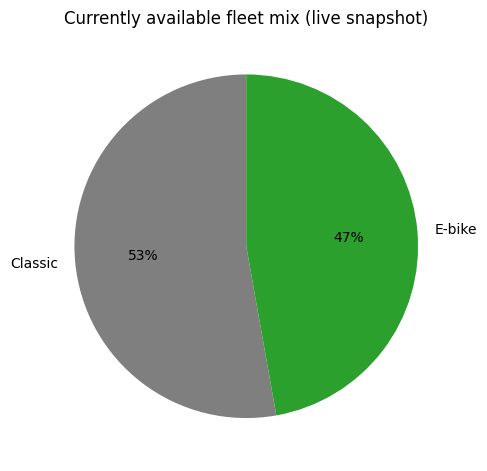

In [6]:
live = fetch_live_station_status()
total_classic = live['num_classic_available'].sum()
total_ebike = live['num_ebike_available'].sum()
print(f"Fleet available right now: {total_classic} classic, {total_ebike} e-bike "
      f"({100*total_ebike/(total_classic+total_ebike):.0f}% e-bike)")

fig, ax = plt.subplots(figsize=(5, 5))
ax.pie([total_classic, total_ebike], labels=['Classic', 'E-bike'], autopct='%1.0f%%',
       colors=['#7f7f7f', '#2ca02c'], startangle=90)
ax.set_title('Currently available fleet mix (live snapshot)')
plt.tight_layout()
plt.savefig('../docs/ebike_classic_split.png', dpi=150)
plt.show()

## 6. Interactive map

Radio toggle between **Live now** (with a Total / E-bikes / Classic
sub-toggle) and **Predicted**, which reveals a slider to scrub through the
7-day-ahead bi-hourly forecast plus its own sub-toggle: **net flow** (the
rate stations are gaining/losing bikes) vs. **predicted bikes available**
(the simulated stock, colored the same way as the live view so the two are
directly comparable) - which itself has a Total / E-bikes / Classic
sub-toggle, mirroring the live view. Bike-infrastructure layers (top-left) can be
toggled independently and overlaid on either mode.

In [7]:
out_path = build_demand_map(future, live, infra, '../docs/station_demand_prediction_map.html')
print(f"map written to {out_path}")

map written to ../docs/station_demand_prediction_map.html


## Takeaways

- **Bi-hourly resolution is noisier but still beats naive**: per-bin counts
  are small (a handful of trips per station per 2-hour window), so absolute
  MAE is small too, but the model still meaningfully beats a per-station
  per-hour historical average (see section 3).
- **E-bike adoption is substantial**: roughly half of currently-available
  bikes are e-bikes - a real operational signal, but only observable live,
  not from historical trip counts.
- **Infrastructure overlays give geographic context** for the demand
  patterns - e.g., check whether high-turnover stations cluster along
  protected lanes/trails vs. streets with only sharrows or no marked
  infrastructure at all.
- Still a volume model, not a full simulation - hour-by-hour predicted flow
  plus live occupancy is exactly the combination a real rebalancing tool
  would use to flag which stations need a truck *this afternoon*.
